In [4]:
#   Importing all the necessary libraries/modules.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import skimage.io as io
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES=True    #   To avoid errors while loading truncated images.
from PIL import Image
import re
import pytesseract
import pickle

In [2]:
dataframe=pd.read_csv("C:\\Users\\Akhil\\OneDrive\\Desktop\\Akhil\\Final project\\execution\\final project\\memes_dataset.csv") #   Reading the data from the specified CSV (.csv) file.
dataframe=dataframe.drop(dataframe.columns[0], axis=1)  #   Dropping the first column of the dataframe.
dataframe["overall_sentiment"]=dataframe["label"].map({"positive":0, "negative":2})    #   Assigning numerical values to the image sentiments.
dataframe=dataframe.sort_values(by=["overall_sentiment"], ascending=True)
dataframe=dataframe.reset_index(drop=True)  #   Resetting the index of the pandas.DataFrame.
dataframe

,text,label,upvotes,overall_sentiment
0,Beyonce BEYONCE BEYTWICE image tagged in beyon...,positive,79.0,0
1,true tho HOBBIESMOTIVATION ME HOBBIESMOTIVATIO...,positive,930.0,0
2,"image tagged in future,funny made w Imgflip me...",positive,5.0,0
3,"30 for 30 meme image tagged in memes,antonio b...",positive,24185.0,0
4,"Oh yeah! 20,000 points! LETS CELEBRATE ME HAVI...",positive,3.0,0
...,...,...,...,...
1677,"image tagged in south korea,korean made w Imgf...",negative,95.0,2
1678,El Ojo De Las Figuras NEVER DO THIS IF YOURE I...,negative,901147.0,2
1679,This is War!! Imgflip is in crisis right now b...,negative,12380.0,2
1680,Imbued can be nonAwakened and still kick undea...,negative,77747.0,2


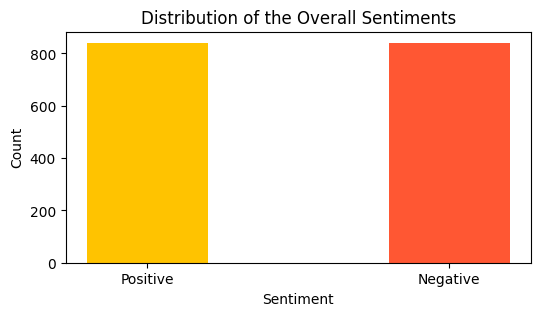

In [5]:
dataframe["overall_sentiment"].value_counts()   #   Finding the count of each sentiment in the pandas.DataFrame.

#   Plotting the distribution of the image sentiments.

plt.figure(figsize=(6, 3))
plt.bar(dataframe["overall_sentiment"].value_counts().index, dataframe["overall_sentiment"].value_counts().values, color=["#FFC300", "#FF5733"])
plt.xticks(dataframe["overall_sentiment"].value_counts().index, ["Positive", "Negative"])
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Distribution of the Overall Sentiments")
plt.show()

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Reading the data
dataframe = pd.read_csv("memes_dataset.csv").drop(dataframe.columns[0], axis=1)
dataframe = dataframe.rename(columns={"overalt": "label"})

# Mapping sentiment labels to numerical values
sentiment_mapping = {"positive": 0, "negative": 1}
dataframe["overall_sentiment"] = dataframe["label"].map(sentiment_mapping)
sentiment_counts = dataframe["overall_sentiment"].value_counts()
majority_class = sentiment_counts.idxmax()  # Most frequent sentiment
minority_class = 1 - majority_class  # The other class
dataframe_majority = dataframe[dataframe["overall_sentiment"] == majority_class]
dataframe_minority = dataframe[dataframe["overall_sentiment"] == minority_class]
if len(dataframe_minority) > 0:  # Ensure minority class exists
    dataframe_minority_upsampled = resample(
        dataframe_minority, replace=True, n_samples=len(dataframe_majority), random_state=42
    )
    dataframe_upsampled = pd.concat([dataframe_majority, dataframe_minority_upsampled])
else:
    dataframe_upsampled = dataframe_majority  # No need to upsample
dataframe_upsampled = dataframe_upsampled.sort_values(by=["overall_sentiment"]).reset_index(drop=True)
print(dataframe_upsampled["overall_sentiment"].value_counts())


overall_sentiment
0    841
1    841
Name: count, dtype: int64


In [12]:
from skimage import io
import os

# Define the correct path to your image folder
image_folder = r"C:\Users\Akhil\OneDrive\Desktop\Akhil\Final project\execution\final project\meme_images"

images = []
for i in range(len(dataframe_upsampled)):
    image_path = os.path.join(image_folder, dataframe_upsampled["image_path"].iloc[i])  # Construct full path
    image = io.imread(image_path)  # Read image
    images.append(image)


In [13]:
#   Splitting the image data into training and testing sets.

train_images, test_images, train_labels, test_labels=train_test_split(images, dataframe_upsampled["overall_sentiment"], test_size=0.2, random_state=52)

#   Converting the training images to greyscale and resizing them to (200 x 200) pixels.

x_train = []
for img in train_images:
    img = np.squeeze(img)  # Fix shape
    img_resized = np.array(Image.fromarray(img).convert("L").resize((200, 200)))
    x_train.append(img_resized)

x_test = []
for img in test_images:
    img = np.squeeze(img)  # Fix shape
    img_resized = np.array(Image.fromarray(img).convert("L").resize((200, 200)))
    x_test.append(img_resized)

# Normalize the images
x_train = np.array(x_train) / 255.0
x_test = np.array(x_test) / 255.0

# Flatten the images for ML models
nsamples, nx, ny = x_train.shape
x_train = x_train.reshape((nsamples, nx * ny))

nsamples, nx, ny = x_test.shape
x_test = x_test.reshape((nsamples, nx * ny))


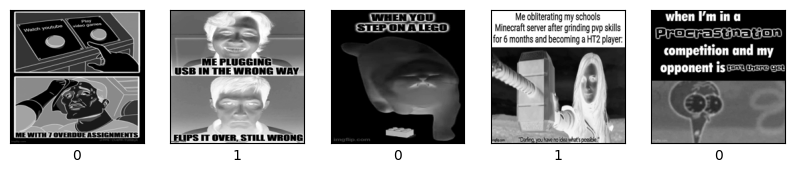

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    # Ensure reshaping works correctly
    image = x_train[i]
    if image.shape != (200, 200):  
        image = image.reshape((200, 200))  # Only reshape if necessary
    
    plt.imshow(image, cmap=plt.cm.binary)
    
    # Convert train_labels to a NumPy array if needed
    if isinstance(train_labels, pd.Series):
        train_labels = train_labels.to_numpy()
    
    plt.xlabel(train_labels[i])  # Ensure train_labels is correctly indexed

plt.show()


In [15]:
#   Scaling the training and testing sets.

ss=StandardScaler() #   Creating an instance of the StandardScaler class.
x_train=ss.fit_transform(x_train)   #   Fitting the instance of the StandardScaler class to the training set and transforming it.
x_test=ss.transform(x_test) #   Transforming the testing set.

In [16]:
rf=RandomForestClassifier(n_estimators=100, criterion="entropy", random_state=42)   #   Creating an instance of the RandomForestClassifier class.
rf.fit(x_train, train_labels)   #   Training the model on the training data.

RandomForestClassifier(criterion='entropy', random_state=42)

In [17]:
rf_predictions=rf.predict(x_test)   #   Predicting the labels of the testing images.
rf_predictions

array([0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,

In [18]:
rf_score=accuracy_score(test_labels, rf_predictions)    #   Calculating the accuracy of the model.
rf_f1_score=f1_score(test_labels, rf_predictions, average="macro")  #   Calculating the average macro F1-score of the model.
print(classification_report(test_labels, rf_predictions))   #   Printing the classification report of the model.
print("Accuracy: ", rf_score*100, "%")
print("F1-Score (Macro): ", rf_f1_score*100, "%")

              precision    recall  f1-score   support

           0       0.72      0.72      0.72       171
           1       0.71      0.70      0.71       166

    accuracy                           0.71       337
   macro avg       0.71      0.71      0.71       337
weighted avg       0.71      0.71      0.71       337

Accuracy:  71.2166172106825 %
F1-Score (Macro):  71.20749033320708 %


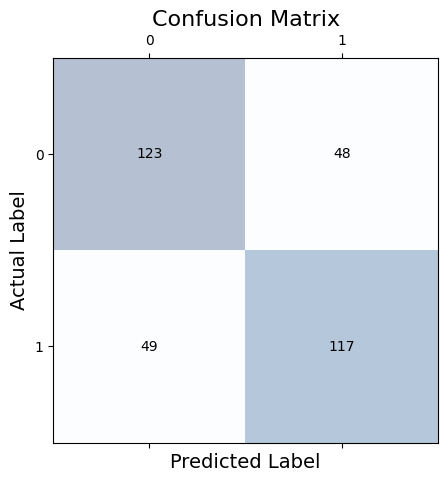

In [19]:
confusion_matrix_rf=confusion_matrix(test_labels, rf_predictions)   #   Creating a confusion matrix for the model.

#   Plotting the confusion matrix.

figure, axis=plt.subplots(figsize=(5, 5))
axis.matshow(confusion_matrix_rf, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confusion_matrix_rf.shape[0]):
    for j in range(confusion_matrix_rf.shape[1]):
        axis.text(x=j, y=i, s=confusion_matrix_rf[i, j], va="center", ha="center")
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()

In [20]:
knc=KNeighborsClassifier(n_neighbors=90, weights="distance", metric="minkowski", p=1)   #   Creating an instance of the KNeighborsClassifier class.
knc.fit(x_train, train_labels)  #   Training the model on the training data.

KNeighborsClassifier(n_neighbors=90, p=1, weights='distance')

In [21]:
knc_predictions=knc.predict(x_test)   #   Predicting the labels of the testing images.
knc_predictions

array([1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,

In [22]:
knc_score=accuracy_score(test_labels, knc_predictions)    #   Calculating the accuracy of the model.
knc_f1_score=f1_score(test_labels, knc_predictions, average="macro")  #   Calculating the average macro F1-score of the model.
print(classification_report(test_labels, knc_predictions))  #   Printing the classification report of the model.
print("Accuracy: ", knc_score*100, "%")
print("F1-Score (Macro): ", knc_f1_score*100, "%")

              precision    recall  f1-score   support

           0       0.71      0.43      0.53       171
           1       0.58      0.82      0.68       166

    accuracy                           0.62       337
   macro avg       0.64      0.62      0.61       337
weighted avg       0.65      0.62      0.61       337

Accuracy:  62.01780415430267 %
F1-Score (Macro):  60.64233576642336 %


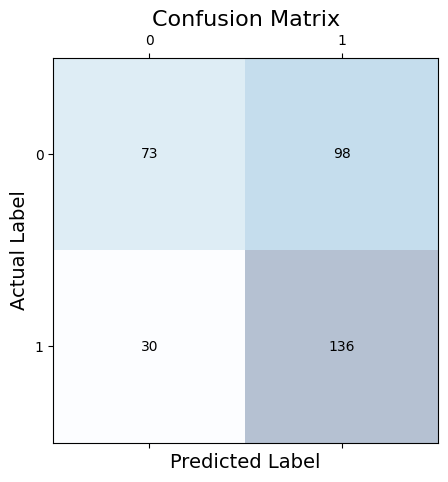

In [23]:
confusion_matrix_knc=confusion_matrix(test_labels, knc_predictions)   #   Creating a confusion matrix for the model.

#   Plotting the confusion matrix.

figure, axis=plt.subplots(figsize=(5, 5))
axis.matshow(confusion_matrix_knc, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confusion_matrix_knc.shape[0]):
    for j in range(confusion_matrix_knc.shape[1]):
        axis.text(x=j, y=i, s=confusion_matrix_knc[i, j], va="center", ha="center")
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()

In [24]:
etc=ExtraTreesClassifier(n_estimators=100, random_state=42) #   Creating an instance of the ExtraTreesClassifier class.
etc.fit(x_train, train_labels)  #   Training the model on the training data.

ExtraTreesClassifier(random_state=42)

In [25]:
etc_predictions=etc.predict(x_test) #   Predicting the labels of the testing images.
etc_predictions

array([0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,

In [26]:
etc_score=accuracy_score(test_labels, etc_predictions)    #   Calculating the accuracy of the model.
etc_f1_score=f1_score(test_labels, etc_predictions, average="macro")  #   Calculating the average macro F1-score of the model.
print(classification_report(test_labels, etc_predictions))  #   Printing the classification report of the model.
print("Accuracy: ", etc_score*100, "%")
print("F1-Score (Macro): ", etc_f1_score*100, "%")

              precision    recall  f1-score   support

           0       0.74      0.87      0.80       171
           1       0.84      0.69      0.76       166

    accuracy                           0.78       337
   macro avg       0.79      0.78      0.78       337
weighted avg       0.79      0.78      0.78       337

Accuracy:  78.33827893175074 %
F1-Score (Macro):  78.1155204469234 %


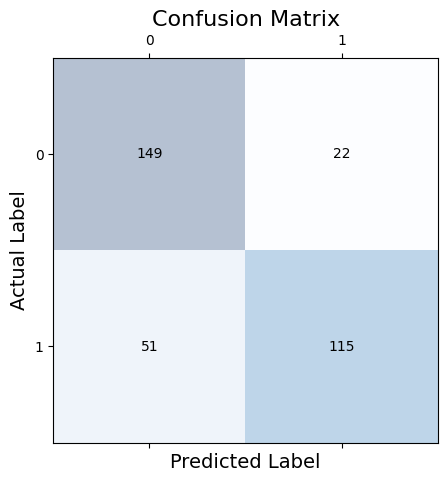

In [27]:
confusion_matrix_etc=confusion_matrix(test_labels, etc_predictions) #   Creating a confusion matrix for the model.

#   Plotting the confusion matrix.

figure, axis=plt.subplots(figsize=(5, 5))
axis.matshow(confusion_matrix_etc, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confusion_matrix_etc.shape[0]):
    for j in range(confusion_matrix_etc.shape[1]):
        axis.text(x=j, y=i, s=confusion_matrix_etc[i, j], va="center", ha="center")
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()

Image:


<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Akhil\AppData\Local\Temp\ipykernel_12960\2060313094.py:1: SyntaxWarning: invalid escape sequence '\m'
  image_path="meme_images\meme_1768_1740464195.jpg"   #   Path of the image to be tested.


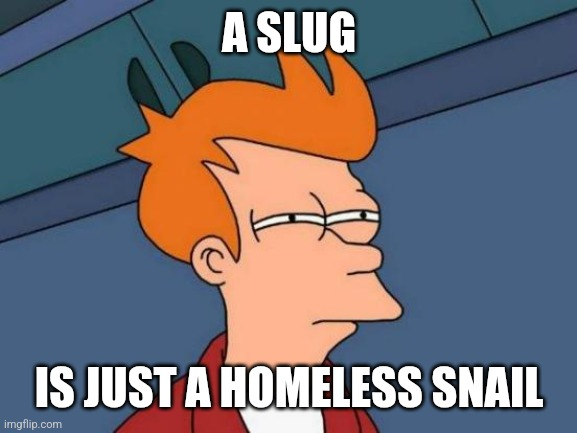

In [32]:
image_path="meme_images\meme_1768_1740464195.jpg"   #   Path of the image to be tested.
image=Image.open(image_path)    #   Opening the image.
print("Image:")
image

In [33]:
image=image.convert("L")    #   Converting the image to grayscale.
image=image.resize((200, 200))  #   Resizing the image to (200 x 200) pixels.
image=np.array(image)   #   Converting the image to a NumPy.Array.
image=np.array(image)/255.0 #   Normalising the image.
nx, ny=image.shape  #   Retrieving the dimensions of the image.
image=image.reshape((1, nx*ny)) #   Reshaping the image to a one-dimensional array.
classes=["positive","negative"]   #   Defining a list of all the classes.
answer=knc.predict(image)  #   Predicting the label of the image.
print("Predicted:", classes[answer[0]])

Predicted: negative


In [31]:
dataframe=pd.read_csv("memes_dataset.csv") #   Reading the data from the specified CSV (.csv) file.
dataframe=dataframe.drop(dataframe.columns[0], axis=1)  #   Dropping the first column of the dataframe.
dataframe["overall_sentiment"]=dataframe["label"].map({"positive":0, "negative":1})    #   Assigning numerical values to the image sentiments.
dataframe=dataframe.sort_values(by=["overall_sentiment"], ascending=True)
dataframe=dataframe.reset_index(drop=True)  #   Resetting the index of the pandas.DataFrame.
dataframe

,text,label,upvotes,overall_sentiment
0,Beyonce BEYONCE BEYTWICE image tagged in beyon...,positive,79.0,0
1,true tho HOBBIESMOTIVATION ME HOBBIESMOTIVATIO...,positive,930.0,0
2,"image tagged in future,funny made w Imgflip me...",positive,5.0,0
3,"30 for 30 meme image tagged in memes,antonio b...",positive,24185.0,0
4,"Oh yeah! 20,000 points! LETS CELEBRATE ME HAVI...",positive,3.0,0
...,...,...,...,...
1677,"image tagged in south korea,korean made w Imgf...",negative,95.0,1
1678,El Ojo De Las Figuras NEVER DO THIS IF YOURE I...,negative,901147.0,1
1679,This is War!! Imgflip is in crisis right now b...,negative,12380.0,1
1680,Imbued can be nonAwakened and still kick undea...,negative,77747.0,1


In [34]:
#   Separating the majority and minority classes.

dataframe_majority=dataframe[dataframe["overall_sentiment"]==1]
dataframe_minority=dataframe[dataframe["overall_sentiment"]!=1]

dataframe_minority_upsampled=resample(dataframe_minority, replace=True, n_samples=len(dataframe_majority), random_state=42) #   Resampling the minority class with replacement.
dataframe_upsampled=pd.concat([dataframe_majority, dataframe_minority_upsampled])   #   Concatenating the majority and minority class pandas.DataFrames.
dataframe_upsampled=dataframe_upsampled.sort_values(by=["overall_sentiment"], ascending=True)   #   Sorting the pandas.DataFrame by the overall sentiment.
dataframe_upsampled=dataframe_upsampled.reset_index(drop=True)  #   Resetting the index of the pandas.DataFrame.
dataframe_upsampled["overall_sentiment"].value_counts() #   Finding the frequencies of each sentiment in the pandas.DataFrame.

overall_sentiment
0    841
1    841
Name: count, dtype: int64

In [35]:
ohe_dataframe=pd.get_dummies(dataframe_upsampled, columns=["overall_sentiment"])    #   Converting all the categorical variables into numerical/dummy variables.
ohe_dataframe

,text,label,upvotes,overall_sentiment_0,overall_sentiment_1
0,Buttholes with wings ACTUALLY ENJOYING GOING O...,positive,276.0,True,False
1,I hate coffee ME AFTER TASTING MY MOMS COFFEE ...,positive,744.0,True,False
2,Finding a good title is often harder than maki...,positive,431.0,True,False
3,we got fortnite gta 6 before gta 6 image tagge...,positive,76687.0,True,False
4,triggerpaul WHEN OPENING THE FRIDGE FOR THE 10...,positive,388.0,True,False
...,...,...,...,...,...
1677,"EPIQUE GUN image tagged in epique,guns,drawing...",negative,242.0,False,True
1678,Captain Renault is shocked to find Claude Rain...,negative,7379.0,False,True
1679,Time to light myself on fire 3 image tagged in...,negative,362.0,False,True
1680,Pink Panther hates that SpongeBob Squarepants ...,negative,374016.0,False,True


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
import numpy as np

# Ensure stopwords are downloaded
import nltk
nltk.download("stopwords")

# Use the correct column ("text" instead of "text_corrected")
vectorizer = TfidfVectorizer(max_features=1000, stop_words=stopwords.words("english"), ngram_range=(1, 2))

# Convert the text data to TF-IDF features
x = vectorizer.fit_transform(ohe_dataframe["text"].values.astype("U"))

# Extract sentiment labels
y = ohe_dataframe[["overall_sentiment_0", "overall_sentiment_1"]].values

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Convert one-hot encoded labels to single class labels
y_train = np.argmax(y_train, axis=1)
y_test = np.argmax(y_test, axis=1)

# Convert sparse matrices to dense arrays
x_train = x_train.toarray()
x_test = x_test.toarray()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Akhil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [38]:
sgd=SGDClassifier(loss="perceptron", penalty="l2", max_iter=100000, random_state=42, n_jobs=-1)    #   Creating an instance of the SGDClassifier class.
sgd.fit(x_train, y_train)   #   Training the model.

SGDClassifier(loss='perceptron', max_iter=100000, n_jobs=-1, random_state=42)

In [39]:
sgd_predictions=sgd.predict(x_test)   #   Predicting the labels of the testing data.
sgd_predictions

array([0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,

In [40]:
sgd_score=accuracy_score(y_test, sgd_predictions)    #   Calculating the accuracy of the model.
sgd_f1_score=f1_score(y_test, sgd_predictions, average="weighted")    #   Calculating the average weighted F1-score of the model.
print(classification_report(y_test, sgd_predictions))   #   Printing the classification report of the model.
print("Accuracy: ", sgd_score*100, "%")
print("F1-Score (Weighted): ", sgd_f1_score*100, "%")

              precision    recall  f1-score   support

           0       0.72      0.76      0.74       180
           1       0.70      0.66      0.68       157

    accuracy                           0.71       337
   macro avg       0.71      0.71      0.71       337
weighted avg       0.71      0.71      0.71       337

Accuracy:  71.2166172106825 %
F1-Score (Weighted):  71.14296121314085 %


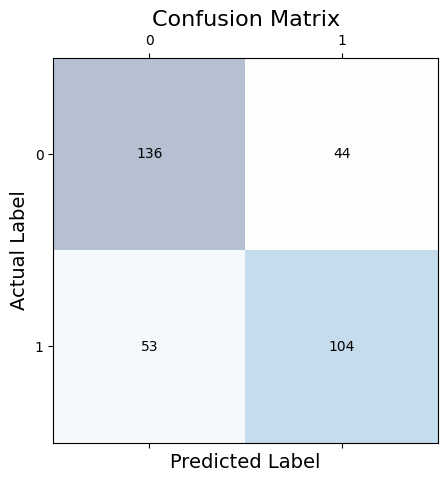

In [41]:
confusion_matrix_sgd=confusion_matrix(y_test, sgd_predictions) #   Creating a confusion matrix for the model.

#   Plotting the confusion matrix.

figure, axis=plt.subplots(figsize=(5, 5))
axis.matshow(confusion_matrix_sgd, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confusion_matrix_sgd.shape[0]):
    for j in range(confusion_matrix_sgd.shape[1]):
        axis.text(x=j, y=i, s=confusion_matrix_sgd[i, j], va="center", ha="center")
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()

In [42]:
mnb=MultinomialNB() #   Creating an instance of the MultinomialNB class.
mnb.fit(x_train, y_train)   #   Training the model on the training data.

MultinomialNB()

In [43]:
mnb_predictions=mnb.predict(x_test)   #   Predicting the labels of the testing data.
mnb_predictions

array([0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0,

In [44]:
mnb_score=accuracy_score(y_test, mnb_predictions)   #   Calculating the accuracy of the model.
mnb_f1_score=f1_score(y_test, mnb_predictions, average="weighted")   #   Calculating the average weighted F1-score of the model.
print(classification_report(y_test, mnb_predictions, zero_division=1))  #   Printing the classification report of the model.
print("Accuracy: ", mnb_score*100, "%")
print("F1-Score (Weighted): ", mnb_f1_score*100, "%")

              precision    recall  f1-score   support

           0       0.76      0.65      0.70       180
           1       0.66      0.76      0.71       157

    accuracy                           0.70       337
   macro avg       0.71      0.71      0.70       337
weighted avg       0.71      0.70      0.70       337

Accuracy:  70.32640949554896 %
F1-Score (Weighted):  70.30602784655858 %


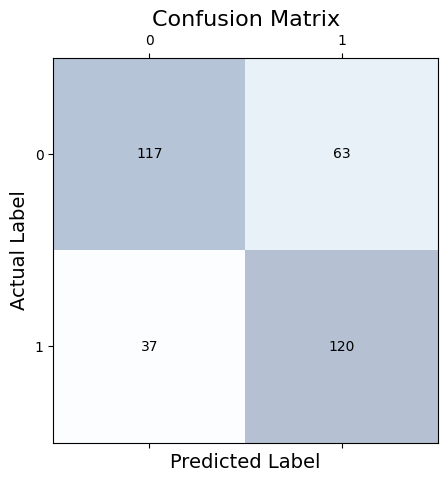

In [45]:
confusion_matrix_mnb=confusion_matrix(y_test, mnb_predictions)   #   Creating a confusion matrix for the model.

#   Plotting the confusion matrix.

figure, axis=plt.subplots(figsize=(5, 5))
axis.matshow(confusion_matrix_mnb, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confusion_matrix_mnb.shape[0]):
    for j in range(confusion_matrix_mnb.shape[1]):
        axis.text(x=j, y=i, s=confusion_matrix_mnb[i, j], va="center", ha="center")
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()

In [46]:
lr=LogisticRegression(solver="liblinear", max_iter=10000, class_weight="balanced", penalty="l2", dual=True) #   Creating an instance of the LogisticRegression class.
lr.fit(x_train, y_train)    #   Training the model on the training data.

LogisticRegression(class_weight='balanced', dual=True, max_iter=10000,
                   solver='liblinear')

In [47]:
lr_predictions=lr.predict(x_test)   #   Predicting the labels of the testing data.
lr_predictionslr_predictions=lr.predict(x_test)   #   Predicting the labels of the testing data.
lr_predictions

array([0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,

In [48]:
lr_score=accuracy_score(y_test, lr_predictions)   #   Calculating the accuracy of the model.
lr_f1_score=f1_score(y_test, lr_predictions, average="weighted")   #   Calculating the average weighted F1-score of the model.
print(classification_report(y_test, lr_predictions))    #   Printing the classification report of the model.
print("Accuracy: ", lr_score*100, "%")
print("F1-Score (Weighted): ", lr_f1_score*100, "%")

              precision    recall  f1-score   support

           0       0.72      0.71      0.71       180
           1       0.67      0.68      0.68       157

    accuracy                           0.69       337
   macro avg       0.69      0.69      0.69       337
weighted avg       0.69      0.69      0.69       337

Accuracy:  69.43620178041543 %
F1-Score (Weighted):  69.4524061110464 %


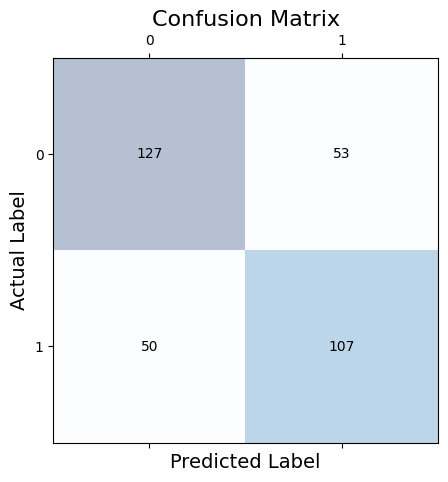

In [49]:
confusion_matrix_lr=confusion_matrix(y_test, lr_predictions)   #   Creating a confusion matrix for the model.

#   Plotting the confusion matrix.

figure, axis=plt.subplots(figsize=(5, 5))
axis.matshow(confusion_matrix_lr, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confusion_matrix_lr.shape[0]):
    for j in range(confusion_matrix_lr.shape[1]):
        axis.text(x=j, y=i, s=confusion_matrix_lr[i, j], va="center", ha="center")
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("Actual Label", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.show()

In [50]:
#   Calculating the average F1-score of all the analyzed classification models.

f1_scores=[rf_f1_score, knc_f1_score, etc_f1_score, sgd_f1_score, mnb_f1_score, lr_f1_score]
print("Average F1-Score: ", sum(f1_scores)/len(f1_scores)*100, "%")

Average F1-Score:  70.14445695288329 %


Image:


<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Akhil\AppData\Local\Temp\ipykernel_12960\1736295124.py:1: SyntaxWarning: invalid escape sequence '\m'
  image_path="meme_images\meme_1759_1740464191.jpg"   #   Path of the image to be tested.


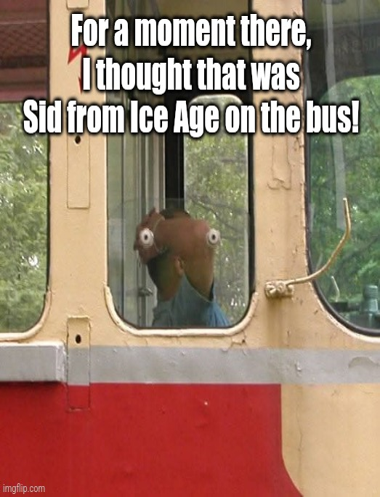

In [51]:
image_path="meme_images\meme_1759_1740464191.jpg"   #   Path of the image to be tested.
image=Image.open(image_path)    #   Opening the image.
image=image.resize((380, 497))  #   Resizing the image.
print("Image:")
image

In [54]:
pytesseract.pytesseract.tesseract_cmd=r"C:\Program Files\Tesseract-OCR\tesseract.exe"   #   Path of the Tesseract executable.
text=pytesseract.image_to_string(image) #   Extracting the text from the image.
print("Text:")
print(text)

Text:
Fora moment there,
amr be

Ssidfrom ice age onthe bus!”

il




In [57]:
import re
import numpy as np

def clean_text(text):
    if isinstance(text, np.ndarray):  # Convert NumPy array to string if needed
        text = text[0]
    text = str(text).lower()  # Ensure text is a string before applying .lower()
    text = re.sub(r"[^a-z0-9]", " ", text)  # Remove all non-alphanumeric characters
    text = re.sub(r"\s+", " ", text).strip()  # Remove extra spaces
    return text

# Example text input (make sure text is a string)
sample_text = "This is a great meme!"

# Cleaning the text
cleaned_text = clean_text(sample_text)

# Transforming the cleaned text using the vectorizer
text_vector = vectorizer.transform([cleaned_text])

# Define class labels
classes = ["positive", "negative"]

# Predicting the label using the trained model
predicted_label = mnb.predict(text_vector)

# Output prediction
print("Predicted:", classes[predicted_label[0]])


Predicted: positive


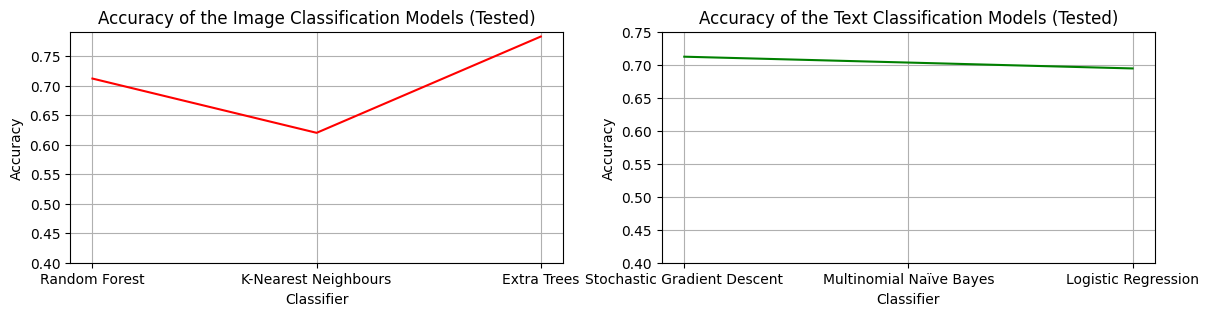

In [58]:
#   Creating a subplot for the figures.

figure, axes=plt.subplots(1, 2, figsize=(14, 3))

#   Plotting the accuracy of the image and text classification models.

axes[0].plot(["Random Forest", "K-Nearest Neighbours", "Extra Trees"], [rf_score, knc_score, etc_score], color="red")
axes[1].plot(["Stochastic Gradient Descent", "Multinomial Naïve Bayes", "Logistic Regression"], [sgd_score, mnb_score, lr_score], color="green")

#   Setting the titles of the figures.

axes[0].set_title("Accuracy of the Image Classification Models (Tested)")
axes[1].set_title("Accuracy of the Text Classification Models (Tested)")

#   Setting the labels of the axes.

axes[0].set_xlabel("Classifier")
axes[1].set_xlabel("Classifier")
axes[0].set_ylabel("Accuracy")
axes[1].set_ylabel("Accuracy")

#   Setting the tick labels of the axes.

axes[0].set_xticks(["Random Forest", "K-Nearest Neighbours", "Extra Trees"])
axes[1].set_xticks(["Stochastic Gradient Descent", "Multinomial Naïve Bayes", "Logistic Regression"])
axes[0].set_yticks(np.arange(0.4, 0.8, 0.05))
axes[1].set_yticks(np.arange(0.4, 0.8, 0.05))

#   Adding a grid to the figures.

axes[0].grid()
axes[1].grid()

plt.show()

In [59]:
#   Exporting all the machine learning classification models into separate pickle (.pkl) files.

pickle.dump(rf, open("rf_model.pkl", "wb"))
pickle.dump(knc, open("knc_model.pkl", "wb"))
pickle.dump(etc, open("etc_model.pkl", "wb"))
pickle.dump(sgd, open("sgd_model.pkl", "wb"))
pickle.dump(mnb, open("mnb_model.pkl", "wb"))
pickle.dump(lr, open("lr_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))